# biPangolin paper figures

This notebook is a figure-generation workspace for the biPangolin manuscript:

1. **Correction optimisation** — empirical sweep + analytical estimate of the None-class correction factor `k`
2. **Example sequence and model runs** — load a worked example for the trace and tissue figures
3. **Effect of correction value on prediction traces** — the example sequence re-plotted at different `k` values, alongside Pangolin and SpliceAI
4. **Pangolin PSI / P(spliced) versus probe confidence** — does the probe fire where Pangolin says there's splicing?
5. **4-track-per-tissue matrix export** — optional NPY dump of the tissue-specific donor/acceptor predictions
6. **Held-out benchmark on chr1 + chr9** — large-scale PR-AUC comparison against SpliceAI and Pangolin alone
7. **Acceptor-vs-donor discrimination at true splice sites** — confusion matrix + signed-difference density showing near-perfect A/D classification given a true site
8. **Correlation analysis across models** — pairwise Spearman correlations between every probe / Pangolin / SpliceAI per-position score column

The notebook saves figures into `paper_figures/` as SVG and PNG.

## 0. Optional dependencies

Run this cell once if the current environment does not already contain the plotting / benchmarking dependencies.
SpliceAI pulls in TensorFlow, so it is intentionally optional.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from adjustText import adjust_text
except ImportError:
    adjust_text = None

from bipangolin import BiPangolinRunner
from bipangolin.runner import score_sequence_or_long_sequence

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linewidth": 0.6,
})

FIG_DIR = Path("paper_figures")
FIG_DIR.mkdir(exist_ok=True)

ACC_COLOR = "#2f80ed"
DON_COLOR = "#eb5757"
NONE_COLOR = "#4f4f4f"
PANGOLIN_COLOR = "#27ae60"
PSI_COLOR = "#9b51e0"

def save_figure(fig, name):
    """Save a figure as SVG and PNG."""
    stem = FIG_DIR / name
    fig.savefig(stem.with_suffix(".svg"), bbox_inches="tight")
    fig.savefig(stem.with_suffix(".png"), bbox_inches="tight")
    print(f"saved {stem.with_suffix('.svg')} and {stem.with_suffix('.png')}")

def tensor_to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)

## 1. Correction optimisation summary

This first panel uses `optimal_correction.json` to show the empirical correction sweep and the analytical estimate. The more intuitive manuscript panel comes below, where the same example sequence is re-plotted after applying `k = 1, 10, 100, 1000` to the probe outputs.

In [2]:
def find_correction_json():
    candidates = [
        Path("src/bipangolin/data/probes/optimal_correction.json"),
        Path("bipangolin_probes/optimal_correction.json"),
    ]
    for path in candidates:
        if path.exists():
            return path

    try:
        from importlib.resources import files
        path = files("bipangolin") / "data" / "probes" / "optimal_correction.json"
        if path.is_file():
            return path
    except Exception:
        pass

    raise FileNotFoundError("Could not find optimal_correction.json")

correction_json = find_correction_json()
correction_json

PosixPath('src/bipangolin/data/probes/optimal_correction.json')

saved paper_figures/figure_correction_optimisation.svg and paper_figures/figure_correction_optimisation.png


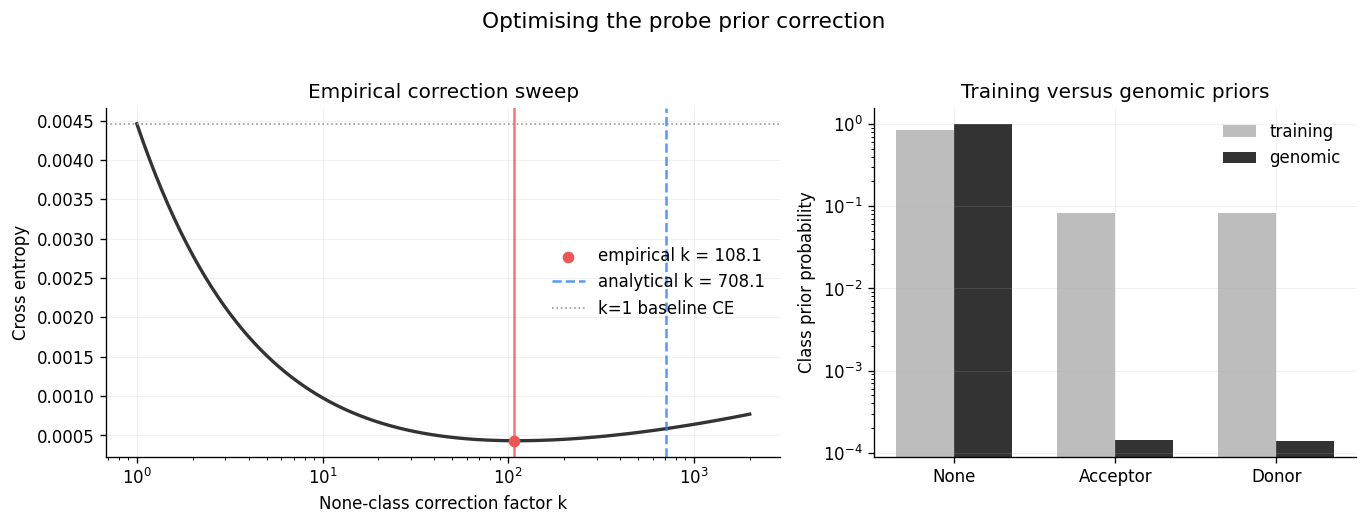

In [3]:
def plot_correction_optimisation(correction_path=correction_json):
    with open(correction_path) as f:
        correction = json.load(f)

    rows = correction["empirical_sweep"]["rows"]
    k = np.array([r["k"] for r in rows], dtype=float)
    ce = np.array([r["cross_entropy"] for r in rows], dtype=float)

    best_k = float(correction["empirical_sweep"]["best_k"])
    analytical_k = float(correction["analytical"]["analytical_k"])
    baseline_ce = float(correction["empirical_sweep"]["baseline_k1_cross_entropy"])

    real_dist = correction["analytical"]["real_distribution"]
    train_dist = correction["analytical"]["training_distribution"]
    classes = ["none", "acc", "don"]
    real = np.array([real_dist[f"p_{c}"] for c in classes])
    train = np.array([train_dist[f"p_{c}"] for c in classes])

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), gridspec_kw={"width_ratios": [1.4, 1]})

    ax = axes[0]
    ax.plot(k, ce, color="#333333", lw=2)
    ax.scatter([best_k], [ce[np.argmin(np.abs(k - best_k))]], color=DON_COLOR, zorder=5, label=f"empirical k = {best_k:.1f}")
    ax.axvline(best_k, color=DON_COLOR, lw=1.5, alpha=0.8)
    ax.axvline(analytical_k, color=ACC_COLOR, lw=1.5, ls="--", alpha=0.8, label=f"analytical k = {analytical_k:.1f}")
    ax.axhline(baseline_ce, color="#999999", lw=1, ls=":", label="k=1 baseline CE")
    ax.set_xscale("log")
    ax.set_xlabel("None-class correction factor k")
    ax.set_ylabel("Cross entropy")
    ax.set_title("Empirical correction sweep")
    ax.legend(frameon=False)

    ax = axes[1]
    x = np.arange(len(classes))
    width = 0.36
    ax.bar(x - width/2, train, width, label="training", color="#bdbdbd")
    ax.bar(x + width/2, real, width, label="genomic", color="#333333")
    ax.set_yscale("log")
    ax.set_xticks(x, ["None", "Acceptor", "Donor"])
    ax.set_ylabel("Class prior probability")
    ax.set_title("Training versus genomic priors")
    ax.legend(frameon=False)

    fig.suptitle("Optimising the probe prior correction", y=1.03, fontsize=13)
    fig.tight_layout()
    return fig, correction

fig, correction = plot_correction_optimisation()
save_figure(fig, "figure_correction_optimisation")
plt.show()

## 2. Example sequence and model runs

This example sequence is used for the correction trace figure and the SpliceAI comparison. Replace `input_sequence` with a gene or region of interest for the final manuscript figure if needed.

In [4]:
input_sequence = """
GGTGCCCGTCAGTGGGCAGAGCGCACATCGCCCACAGTCCCCGAGAAGTTGGGGGGAGGGGTCGGCAATTGAACCGGTGCCTAGAGAAGGTGGCGCGGGGTAAACTGGGAAAGTGATGTCGTGTACTGGCTCCGCCTTTTTCCCGAGGGTGGGGGAGAACCGTATATAAGTGCAGTAGTCGCCGTGAACGTTCTTTTTCGCAACGGGTTTGCCGCCAGAACACAGGTAAGTGCCGTGTGTGGTTCCCGCGGGCCTGGCCTCTTTACGGGTTATGGCCCTTGCGTGCCTTGAATTACTTCCACGCCCCTGGCTGCAGTACGTGATTCTTGATCCCGAGCTTCGGGTTGGAAGTGGGTGGGAGAGTTCGAGGCCTTGCGCTTAAGGAGCCCCTTCGCCTCGTGCTTGAGTTGAGGCCTGGCTTGGGCGCTGGGGCCGCCGCGTGCGAATCTGGTGGCACCTTCGCGCCTGTCTCGCTGCTTTCGATAAGTCTCTAGCCATTTAAAATTTTTGATGACCTGCTGCGACGCTTTTTTTCTGGCAAGATAGTCTTGTAAATGCGGGCCAAGATCTGCACACTGGTATTTCGGTTTTTGGGGCCGCGGGCGGCGACGGGGCCCGTGCGTCCCAGCGCACATGTTCGGCGAGGCGGGGCCTGCGAGCGCGGCCACCGAGAATCGGACGGGGGTAGTCTCAAGCTGGCCGGCCTGCTCTGGTGCCTGGCCTCGCGCCGCCGTGTATCGCCCCGCCCTGGGCGGCAAGGCTGGCCCGGTCGGCACCAGTTGCGTGAGCGGAAAGATGGCCGCTTCCCGGCCCTGCTGCAGGGAGCTCAAAATGGAGGACGCGGCGCTCGGGAGAGCGGGCGGGTGAGTCACCCACACAAAGGAAAAGGGCCTTTCCGTCCTCAGCCGTCGCTTCATGTGACTCCACGGAGTACCGGGCGCCGTCCAGGCACCTCGATTAGTTCTCGAGCTTTTGGAGTACGTCGTCTTTAGGTTGGGGGGAGGGGTTTTATGCGATGGAGTTTCCCCACACTGAGTGGGTGGAGACTGAAGTTAGGCCAGCTTGGCACTTGATGTAATTCTCCTTGGAATTTGCCCTTTTTGAGTTTGGATCTTGGTTCATTCTCAAGCCTCAGACAGTGGTTCAAAGTTTTTTTCTTCCATTTCAGGTGTCGTGAGAGCTCGTTTAGTGAACCGTCAGATCGCCTGGAGACGCCATCCACGCTGTTTTGACCTCCATAGAAGAATCTTTGTCGATCCTACCATCCACTCGACACACCCGCCAGCGGCCGCTTCTTGGTGCCAGCTTATCAGCCACCATGGTGAGCAAGGGCGAGGAGCTGTTCACCGGGGTGGTGCCCATCCTGGTCGAGCTGGACGGCGACGTAAACGGCCACAAGTTCAGCGTCCGCGGCGAGGGCGAGGGCGATGCCACCAACGGCAAGCTGACCCTGAAGTTCATCTGCACCACCGGCAAGCTGCCCGTGCCCTGGCCCACCCTCGTGACCACCTTAGGCTACGGCGTGGCCTGCTTCGCCCGCTACCCCGACCACATGAAGCAGCACGACTTCTTCAAGTCCGCCATGCCCGAAGGCTACGTCCAGGAGCGCACCATCTCTTTCAAGGACGACGGTACCTACAAGACCCGCGCCGAGGTGAAGTTCGAGGGCGACACCCTGGTGAACCGCATCGTGCTGAAGGGCATCGACTTCAAGGAGGACGGCAACATCCTGGGGCACAAGCTGGAGTACAACTTCAACAGCCACAAGGTCTATATCACGGCCGACAAGCAGAAGAACGGCATCAAGGCTAACTTCAAGACCCGCCACAACGTTGAGGACGGCGGCGTGCAGCTCGCCGACCACTACCAGCAGAACACCCCCATCGGCGACGGCCCCGTGCTGCTGCCCGACAACCACTACCTGAGCCATCAGTCCAAACTGAGCAAAGACCCCAACGAGAAGCGCGATCACATGGTCCTGAAGGAGAGGGTGACCGCCGCCGGGATTACACATGACATGGATGAACTATATAAATAATTAATGCGCGTCCTGGTAAGTTGACGACTTTTCCCTTTGGGATAATGGGGCGGGGACGGGGAAACTATGGACTAACTAACCATTTCTCTTTTTCTGTGTGTGTGTGTGAAGTGTGTGTGTGTGTGTGCGGACGCCGATGAACGACGACGACGTCCACATATAATGATATGTTCCCTCCAGGATTCGCGGAAACGCGTACATCCAGCTGACGAGTCCCAAATAGGACGAAACGCGCATTAACGCAGGCCTCTGCTAGCTTGACTGACTGAGATACAGCGTACCTTCAGCTCACGCGGCCGCTTTCTCCGCGATCCAGACATGATAAGATACATTGATGAGTTTGGACAAACCAAAACTAG
""".replace("\n", "").upper()

len(input_sequence)

2397

In [5]:
import os
import subprocess
import sys
import tempfile
import textwrap

def get_spliceai_probs_subprocess(input_sequence, context=10000, python_exe=None):
    """Run SpliceAI in a fresh Python subprocess to avoid TF / torch crashes."""
    script = textwrap.dedent('''
        import sys, numpy as np
        seq = sys.argv[1]
        context = int(sys.argv[2])
        out_path = sys.argv[3]

        from pkg_resources import resource_filename
        from tensorflow.keras.models import load_model
        from spliceai.utils import one_hot_encode

        models = [load_model(resource_filename("spliceai", f"models/spliceai{i}.h5")) for i in range(1, 6)]
        x = one_hot_encode("N" * (context // 2) + seq + "N" * (context // 2))[None, :]
        y = np.mean([m.predict(x, verbose=0) for m in models], axis=0)
        np.savez(out_path, acceptor=y[0, :, 1], donor=y[0, :, 2])
    ''')

    with tempfile.NamedTemporaryFile("w", suffix=".py", delete=False) as f:
        f.write(script)
        script_path = f.name
    out_fd, out_path = tempfile.mkstemp(suffix=".npz")
    os.close(out_fd)
    try:
        subprocess.run(
            [python_exe or sys.executable, script_path, input_sequence, str(context), out_path],
            check=True,
        )
        data = np.load(out_path)
        acc = data["acceptor"]
        don = data["donor"]
        return acc, don, np.arange(len(acc))
    finally:
        for p in (script_path, out_path):
            if os.path.exists(p):
                os.unlink(p)

try:
    spliceai_acceptor, spliceai_donor, nt_pos = get_spliceai_probs_subprocess(input_sequence)
except Exception as e:
    spliceai_acceptor = spliceai_donor = nt_pos = None
    warnings.warn(f"SpliceAI could not be loaded/run: {e}")


/var/folders/kr/crxb3xqd4wv1ysx_0t4zgxv80000gn/T/tmp9qjsksk4.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## 3. Figure: effect of correction value on prediction traces

This figure runs biPangolin once with `correction_k=1.0`, then applies different None-class correction values post hoc. Because the correction only rescales the three probe probabilities, this gives the same probe traces as rerunning the model with each `correction_k`, without wasting compute.

biPangolin: 12 model+probe pairs ready on mps
biPangolin: + 12 PSI-tuned models for PSI predictions
saved paper_figures/figure_correction_value_traces.svg and paper_figures/figure_correction_value_traces.png


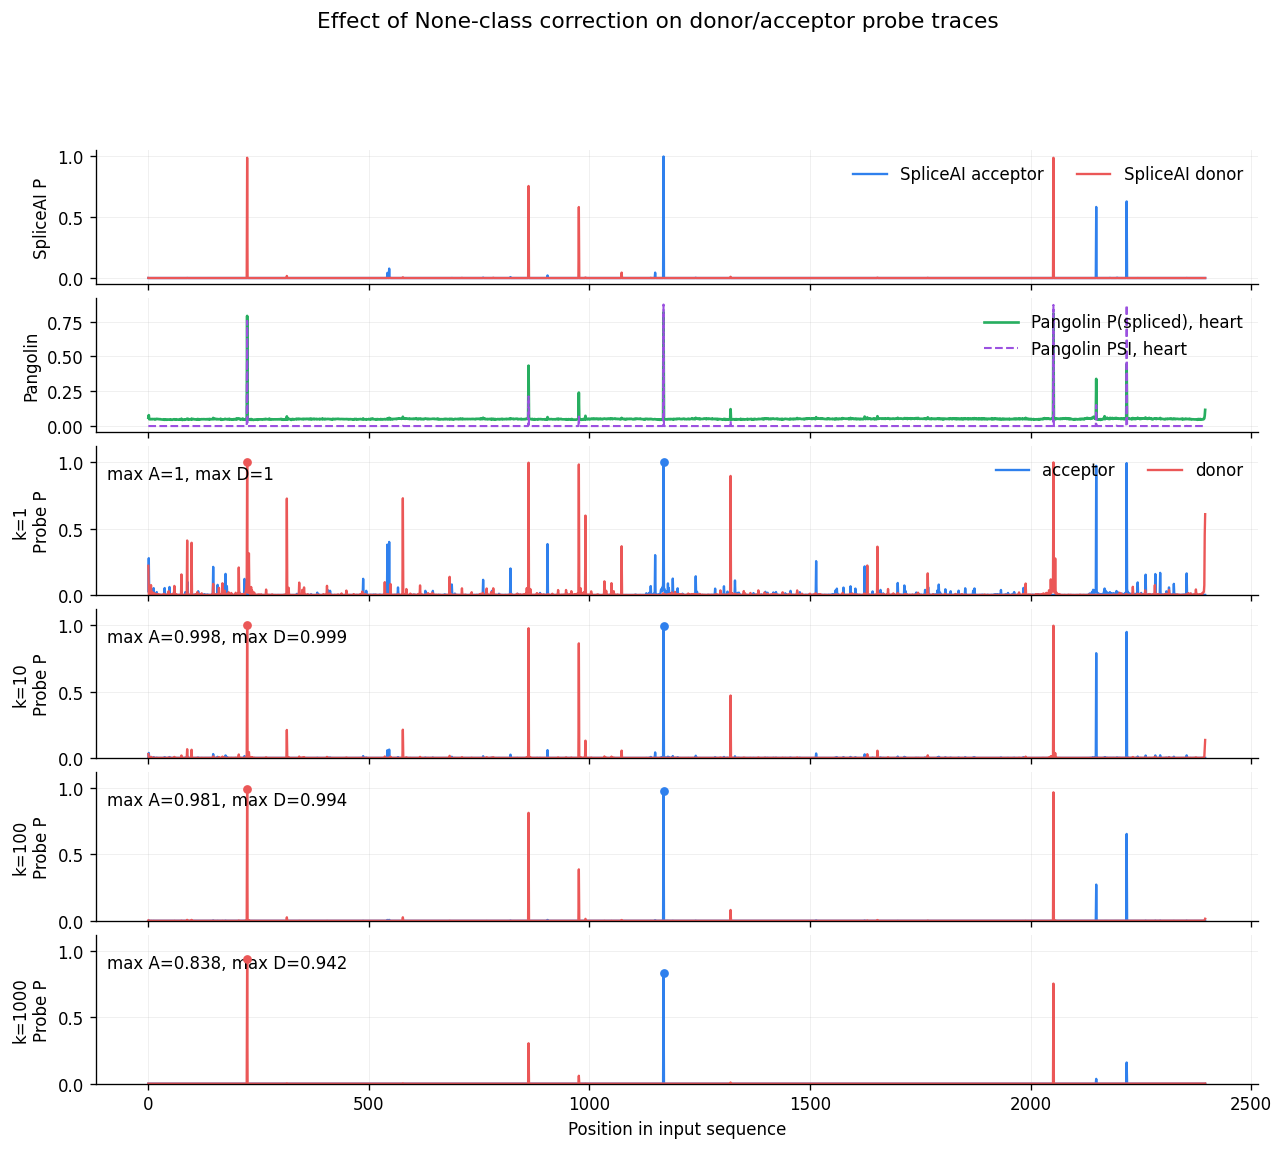

In [6]:
def apply_probe_correction(result, k):
    """Apply None-class correction k to an existing BiPangolinResult's probe tracks."""
    probs = np.stack([
        tensor_to_numpy(result.probe_none),
        tensor_to_numpy(result.probe_acceptor),
        tensor_to_numpy(result.probe_donor),
    ], axis=0).astype(float)
    probs[0] *= float(k)
    probs /= np.clip(probs.sum(axis=0, keepdims=True), 1e-12, None)
    return {
        "none": probs[0],
        "acceptor": probs[1],
        "donor": probs[2],
    }

def plot_correction_value_traces(
    raw_result,
    correction_values=(1, 10, 100, 1000),
    start=0,
    end=None,
    spliceai_acceptor=None,
    spliceai_donor=None,
    spliceai_x=None,
):
    if end is None:
        end = len(raw_result)
    x = np.arange(start, end)

    pangolin_p = tensor_to_numpy(raw_result.pangolin_prob)[0, start:end]
    _psi = raw_result.pangolin_psi
    pangolin_psi = tensor_to_numpy(_psi)[0, start:end] if _psi is not None else None
    tissue = raw_result.tissues[0]

    corrected = {k: apply_probe_correction(raw_result, k) for k in correction_values}
    shared_ymax = max(
        max(corrected[k]["acceptor"][start:end].max(), corrected[k]["donor"][start:end].max())
        for k in correction_values
    )
    shared_ymax = max(0.01, shared_ymax * 1.12)

    has_spliceai = spliceai_acceptor is not None
    nrows = (1 if has_spliceai else 0) + 1 + len(correction_values)
    height_ratios = ([0.9] if has_spliceai else []) + [0.9] + [1] * len(correction_values)

    fig, axes = plt.subplots(
        nrows, 1,
        figsize=(12.5, 2.0 + 1.35 * nrows),
        sharex=True,
        gridspec_kw={"height_ratios": height_ratios, "hspace": 0.10},
    )
    axes = np.asarray(axes).ravel()

    row = 0
    if has_spliceai:
        sai_x = np.asarray(spliceai_x) if spliceai_x is not None else np.arange(len(spliceai_acceptor))
        mask = (sai_x >= start) & (sai_x < end)
        ax = axes[row]
        ax.plot(sai_x[mask], np.asarray(spliceai_acceptor)[mask], color=ACC_COLOR, lw=1.4, label="SpliceAI acceptor")
        ax.plot(sai_x[mask], np.asarray(spliceai_donor)[mask], color=DON_COLOR, lw=1.4, label="SpliceAI donor")
        ax.set_ylabel("SpliceAI P")
        ax.legend(frameon=False, loc="upper right", ncols=2)
        row += 1

    ax = axes[row]
    ax.plot(x, pangolin_p, color=PANGOLIN_COLOR, lw=1.6, label=f"Pangolin P(spliced), {tissue}")
    if pangolin_psi is not None:
        ax.plot(x, pangolin_psi, color=PSI_COLOR, lw=1.25, ls="--", label=f"Pangolin PSI, {tissue}")
    ax.set_ylabel("Pangolin")
    ax.legend(frameon=False, loc="upper right")
    row += 1

    for i, k in enumerate(correction_values):
        ax = axes[row]
        acc = corrected[k]["acceptor"][start:end]
        don = corrected[k]["donor"][start:end]
        ax.fill_between(x, acc, color=ACC_COLOR, alpha=0.18, lw=0)
        ax.plot(x, acc, color=ACC_COLOR, lw=1.4, label="acceptor")
        ax.fill_between(x, don, color=DON_COLOR, alpha=0.18, lw=0)
        ax.plot(x, don, color=DON_COLOR, lw=1.4, label="donor")
        ax.set_ylabel(f"k={k}\nProbe P")
        ax.set_ylim(0, shared_ymax)

        acc_peak = int(np.argmax(acc)) + start
        don_peak = int(np.argmax(don)) + start
        ax.scatter([acc_peak], [corrected[k]["acceptor"][acc_peak]], color=ACC_COLOR, s=18, zorder=4)
        ax.scatter([don_peak], [corrected[k]["donor"][don_peak]], color=DON_COLOR, s=18, zorder=4)
        ax.text(0.01, 0.78, f"max A={acc.max():.3g}, max D={don.max():.3g}", transform=ax.transAxes)
        if i == 0:
            ax.legend(frameon=False, loc="upper right", ncols=2)
        row += 1

    axes[-1].set_xlabel("Position in input sequence")
    fig.suptitle("Effect of None-class correction on donor/acceptor probe traces", y=0.995, fontsize=13)
    return fig

# Raw / uncorrected probe probabilities. Pangolin P and PSI are unchanged by k.
raw_runner = BiPangolinRunner(tissue="all_tissues", correction_k=1.0, use_psi_models=True)
raw_result = raw_runner.score_sequence(input_sequence)

fig = plot_correction_value_traces(
    raw_result,
    correction_values=(1, 10, 100, 1000),
    spliceai_acceptor=globals().get("spliceai_acceptor"),
    spliceai_donor=globals().get("spliceai_donor"),
    spliceai_x=globals().get("nt_pos"),
)
save_figure(fig, "figure_correction_value_traces")
plt.show()


In [7]:
# Use one tissue for simple example plots. Use tissue="all_tissues" for all tissue rows.
# use_psi_models=True loads the PSI-tuned Pangolin weight files in addition to
# the P-tuned ones, so result.pangolin_psi is populated. Doubles Pangolin
# inference compute, which is negligible at this scale.
runner = BiPangolinRunner(tissue="testis", use_psi_models=True)
bp_result = runner.score_sequence(input_sequence)
bp_result


biPangolin: 3 model+probe pairs ready on mps
biPangolin: + 3 PSI-tuned models for PSI predictions
biPangolin: correction k=108.1


BiPangolinResult(pangolin_prob=tensor([[0.0603, 0.0655, 0.0534,  ..., 0.0538, 0.0798, 0.0915]]), probe_none=tensor([0.9979, 0.9963, 0.9999,  ..., 0.9991, 0.9932, 0.9891]), probe_acceptor=tensor([1.9753e-04, 3.6451e-03, 9.4331e-05,  ..., 3.6825e-06, 4.5066e-06,
        5.3344e-06]), probe_donor=tensor([1.9145e-03, 1.4525e-05, 1.6008e-05,  ..., 8.9782e-04, 6.8374e-03,
        1.0850e-02]), tissues=('testis',), pangolin_psi=tensor([[2.4726e-04, 5.9674e-04, 4.9204e-06,  ..., 9.2056e-05, 7.0735e-03,
         2.8527e-02]]), metadata={'length': 2397, 'tiled': False}, probe_per_tissue=None)

## 4. Figure: Pangolin PSI / P(spliced) versus probe confidence

This figure asks whether the probe is confident specifically where Pangolin reports strong splicing signal.

saved paper_figures/figure_pangolin_vs_probe_confidence.svg and paper_figures/figure_pangolin_vs_probe_confidence.png


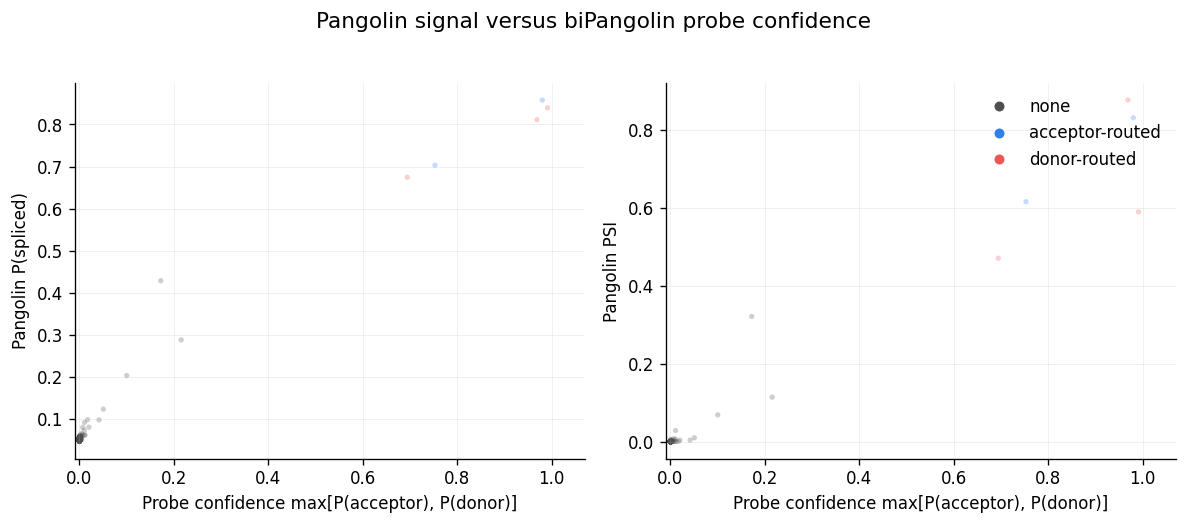

In [8]:
def plot_pangolin_vs_probe_confidence(result):
    probe_none = tensor_to_numpy(result.probe_none)
    probe_acc = tensor_to_numpy(result.probe_acceptor)
    probe_don = tensor_to_numpy(result.probe_donor)
    probe_conf = np.maximum(probe_acc, probe_don)
    probe_label_idx = np.stack([probe_none, probe_acc, probe_don], axis=0).argmax(axis=0)
    color_map = np.array([NONE_COLOR, ACC_COLOR, DON_COLOR])
    colors = color_map[probe_label_idx]

    pangolin_prob = tensor_to_numpy(result.pangolin_prob)
    has_psi = result.pangolin_psi is not None
    pangolin_psi = tensor_to_numpy(result.pangolin_psi) if has_psi else None

    ncols = 2 if has_psi else 1
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4.2), sharex=True, squeeze=False)
    axes = axes[0]  # 1D
    for tissue_idx, tissue in enumerate(result.tissues):
        axes[0].scatter(probe_conf, pangolin_prob[tissue_idx], s=10, alpha=0.28,
                        c=colors, edgecolor="none",
                        label=tissue if tissue_idx == 0 else None)
        if has_psi:
            axes[1].scatter(probe_conf, pangolin_psi[tissue_idx], s=10, alpha=0.28,
                            c=colors, edgecolor="none")

    axes[0].set_ylabel("Pangolin P(spliced)")
    if has_psi:
        axes[1].set_ylabel("Pangolin PSI")
    for ax in axes:
        ax.set_xlabel("Probe confidence max[P(acceptor), P(donor)]")
        ax.set_xlim(-0.01, max(0.05, probe_conf.max() * 1.08))

    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=NONE_COLOR, label="none", markersize=7),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=ACC_COLOR, label="acceptor-routed", markersize=7),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=DON_COLOR, label="donor-routed", markersize=7),
    ]
    axes[-1].legend(handles=handles, frameon=False, loc="upper right")
    suptitle = "Pangolin signal versus biPangolin probe confidence"
    if not has_psi:
        suptitle += "  (PSI not loaded; pass use_psi_models=True to BiPangolinRunner)"
    fig.suptitle(suptitle, y=1.03, fontsize=13)
    fig.tight_layout()
    return fig

fig = plot_pangolin_vs_probe_confidence(bp_result)
save_figure(fig, "figure_pangolin_vs_probe_confidence")
plt.show()


## 5. Optional: export the 4-track-per-tissue matrix

Channel order:

0. donor PSI
1. donor P(spliced)
2. acceptor PSI
3. acceptor P(spliced)

In [9]:
# four_track_per_tissue requires the runner to have been built with
# use_psi_models=True (because two of the four channels are PSI). The runner
# in the previous cell sets this, so this just works.
four_track = bp_result.four_track_per_tissue().detach().cpu().numpy()
np.save(FIG_DIR / "example_four_track_per_tissue.npy", four_track)
four_track.shape


(4, 1, 2397)

## 6. Held-out benchmark: chr1 + chr9

Large-scale comparison on the held-out test chromosomes (chr1, chr9 — forward strand only, same TSS/TTS-aware labelling as training).

The actual model inference is done outside the notebook by `benchmark/bench_score.py` (writes `bench_scores/{chrom}.parquet`). Metrics are computed by `benchmark/bench_metrics.py` (writes `bench_metrics/summary.csv`).

This section loads those artifacts and produces:

1. PR-AUC bar chart by method × task (the headline figure)
2. Score distributions at true acceptor / donor sites
3. Overlaid PR curves
4. Top-N recall

Run the benchmark scripts first if `bench_metrics/summary.csv` doesn't exist.

In [10]:
# Load the benchmark summary CSV produced by `benchmark/bench_metrics.py`.

import pandas as pd

BENCH_SCORES_DIR = Path("bench_scores")
BENCH_METRICS_CSV = Path("bench_metrics/summary.csv")

if not BENCH_METRICS_CSV.exists():
    raise FileNotFoundError(
        f"{BENCH_METRICS_CSV} not found. Run:\n"
        "  python benchmark/bench_metrics.py --scores bench_scores/ --out bench_metrics/summary.csv"
    )

bench_summary = pd.read_csv(BENCH_METRICS_CSV)
print(f"loaded {len(bench_summary):,} rows from {BENCH_METRICS_CSV}")
print("chroms:   ", sorted(bench_summary['chrom'].unique()))
print("methods:  ", sorted(bench_summary['method'].unique()))
print("tasks:    ", sorted(bench_summary['task'].unique()))
print("metrics:  ", sorted(bench_summary['metric'].unique()))
bench_summary.head()

loaded 426 rows from bench_metrics/summary.csv
chroms:    ['ALL', 'chr1', 'chr9']
methods:   ['biPangolin_k0', 'biPangolin_k1', 'biPangolin_k10', 'biPangolin_k100', 'biPangolin_k1000', 'biPangolin_k108', 'biPangolin_k708', 'pangolin_p_brain', 'pangolin_p_heart', 'pangolin_p_liver', 'pangolin_p_testis', 'pangolin_psi_brain', 'pangolin_psi_heart', 'pangolin_psi_liver', 'pangolin_psi_testis', 'spliceai']
tasks:     ['3class_argmax', 'acceptor', 'any_site', 'donor']
metrics:   ['accuracy_all', 'accuracy_at_truesites', 'pr_auc', 'roc_auc', 'top_n_precision', 'top_n_recall']


,chrom,method,task,metric,value,n_pos,n_total
0,chr1,biPangolin_k0,acceptor,pr_auc,0.607379,16041,134872235
1,chr1,biPangolin_k0,acceptor,roc_auc,0.997372,16041,134872235
2,chr1,biPangolin_k0,acceptor,top_n_recall,0.611184,16041,134872235
3,chr1,biPangolin_k0,acceptor,top_n_precision,0.611184,16041,134872235
4,chr1,biPangolin_k0,donor,pr_auc,0.623392,15943,134872235


saved paper_figures/figure_benchmark_prauc.svg and paper_figures/figure_benchmark_prauc.png


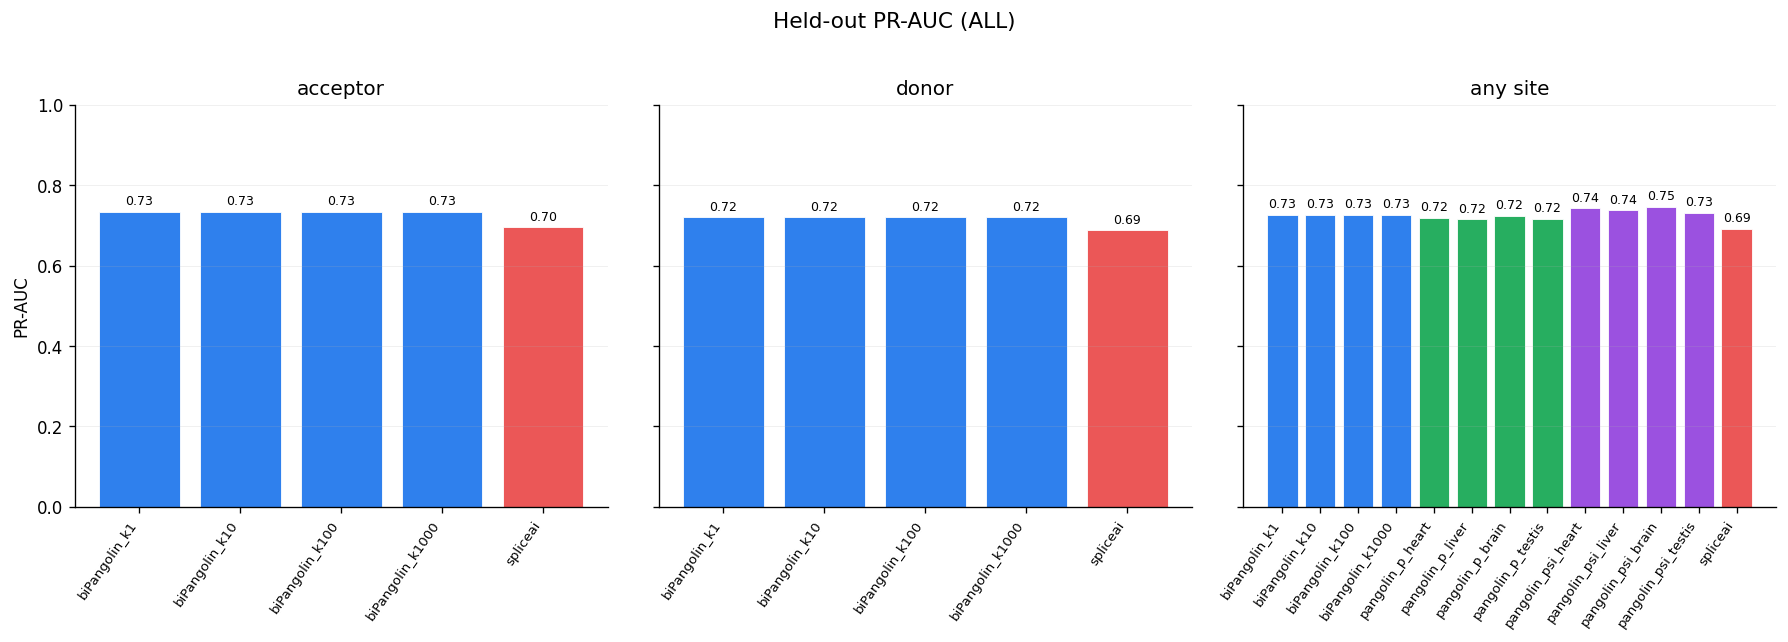

In [11]:
# Headline figure: PR-AUC by method × task on pooled chr1+chr9 (chrom=='ALL').

BENCH_METHOD_ORDER = [
    "biPangolin_k1", "biPangolin_k10",
    "biPangolin_k100", "biPangolin_k502", "biPangolin_k1000",
    "biPangolin_psi_k1", "biPangolin_psi_k10",
    "biPangolin_psi_k100", "biPangolin_psi_k502", "biPangolin_psi_k1000",
    "pangolin_p_heart", "pangolin_p_liver", "pangolin_p_brain", "pangolin_p_testis",
    "pangolin_psi_heart", "pangolin_psi_liver", "pangolin_psi_brain", "pangolin_psi_testis",
    "spliceai",
]
BENCH_METHOD_COLOR = {}
for m in BENCH_METHOD_ORDER:
    if m.startswith("biPangolin_psi"):
        BENCH_METHOD_COLOR[m] = "#7b68ee"  # PSI-side probe — purple-blue
    elif m.startswith("biPangolin"):
        BENCH_METHOD_COLOR[m] = "#2f80ed"
    elif m.startswith("pangolin_p_"):
        BENCH_METHOD_COLOR[m] = "#27ae60"
    elif m.startswith("pangolin_psi_"):
        BENCH_METHOD_COLOR[m] = "#9b51e0"
    else:
        BENCH_METHOD_COLOR[m] = "#eb5757"  # SpliceAI

def plot_benchmark_prauc(summary, chrom="ALL", tasks=("acceptor", "donor", "any_site")):
    df = summary[(summary["chrom"] == chrom)
                 & (summary["metric"] == "pr_auc")
                 & (summary["task"].isin(tasks))].copy()
    if df.empty:
        raise ValueError(f"No PR-AUC rows for chrom={chrom!r}")
    # Keep only methods we know about, in our preferred order.
    df = df[df["method"].isin(BENCH_METHOD_ORDER)]
    df["method"] = pd.Categorical(df["method"], categories=BENCH_METHOD_ORDER, ordered=True)
    df = df.sort_values("method")

    fig, axes = plt.subplots(1, len(tasks), figsize=(5 * len(tasks), 5.2), sharey=True)
    if len(tasks) == 1:
        axes = [axes]
    for ax, task in zip(axes, tasks):
        sub = df[df["task"] == task]
        x = np.arange(len(sub))
        colors = [BENCH_METHOD_COLOR.get(m, "#888888") for m in sub["method"]]
        ax.bar(x, sub["value"], color=colors, edgecolor="white", linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["method"], rotation=55, ha="right", fontsize=8)
        ax.set_title(task.replace("_", " "))
        ax.set_ylim(0, 1)
        ax.grid(axis="x", visible=False)
        for xi, v in zip(x, sub["value"]):
            if pd.notna(v):
                ax.text(xi, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=7.5)
    axes[0].set_ylabel("PR-AUC")
    fig.suptitle(f"Held-out PR-AUC ({chrom})", y=1.02, fontsize=13)
    fig.tight_layout()
    return fig

fig = plot_benchmark_prauc(bench_summary)
save_figure(fig, "figure_benchmark_prauc")
plt.show()

In [12]:
# Load the raw parquet (memory-efficient column-selective read).
# We need: label + the score columns we plot. We DON'T need chrom/gene_id/pos for these analyses.
#
# Probe outputs are stored in the parquet at correction_k=1.0 (raw softmax). We
# apply the Bayesian none-class correction at load time, defaulting to the
# production k from optimal_correction.json (~502). Pass correction_k=1.0 if
# you specifically want to look at raw outputs.

import pyarrow.parquet as pq

# Set to ["chr1", "chr9"] for final paper figures; chr9-only for quick local runs.
BENCH_CHROMS = ["chr9"]


def _resolve_default_correction_k():
    """Read best_k from src/bipangolin/data/probes/optimal_correction.json."""
    for p in (Path("src/bipangolin/data/probes/optimal_correction.json"),
              Path("bipangolin_probes/optimal_correction.json")):
        if p.exists():
            with open(p) as f:
                return float(json.load(f)["empirical_sweep"]["best_k"])
    return 502.0  # safe fallback


def load_bench_arrays(chroms=BENCH_CHROMS, scores_dir=BENCH_SCORES_DIR,
                     correction_k=None):
    if correction_k is None:
        correction_k = _resolve_default_correction_k()

    cols = [
        "label",
        "probe_none", "probe_acc", "probe_don",
        "pangolin_p_heart", "pangolin_p_liver", "pangolin_p_brain", "pangolin_p_testis",
        "pangolin_psi_heart", "pangolin_psi_liver", "pangolin_psi_brain", "pangolin_psi_testis",
        "spliceai_acc", "spliceai_don",
    ]
    tables = []
    for chrom in chroms:
        path = scores_dir / f"{chrom}.parquet"
        print(f"  reading {path} ...")
        tables.append(pq.read_table(str(path), columns=cols))
    table = pa.concat_tables(tables)
    print(f"  total rows: {table.num_rows:,}   applying correction_k = {correction_k}")
    arrays = {}
    for c in cols:
        a = table[c].to_numpy()
        if c == "label":
            arrays[c] = a.astype(np.int8)
        else:
            arrays[c] = a.astype(np.float32)

    # Apply Bayesian correction to probe triple (ensemble).
    if correction_k != 1.0:
        k = np.float32(correction_k)
        pn, pa_, pd_ = arrays["probe_none"], arrays["probe_acc"], arrays["probe_don"]
        s = pn * k + pa_ + pd_
        s = np.maximum(s, np.float32(1e-12))
        arrays["probe_none"] = (pn * k) / s
        arrays["probe_acc"]  = pa_ / s
        arrays["probe_don"]  = pd_ / s
    arrays["_correction_k"] = correction_k
    return arrays


import pyarrow as pa
bench_arrays = load_bench_arrays()

label = bench_arrays["label"]
print(f"  acceptors: {int((label==1).sum()):,}   donors: {int((label==2).sum()):,}   "
      f"none: {int((label==0).sum()):,}")


  reading bench_scores/chr9.parquet ...
  total rows: 63,900,359   applying correction_k = 108.13542142817668
  acceptors: 7,194   donors: 7,110   none: 63,886,055


saved paper_figures/figure_benchmark_score_distributions.svg and paper_figures/figure_benchmark_score_distributions.png


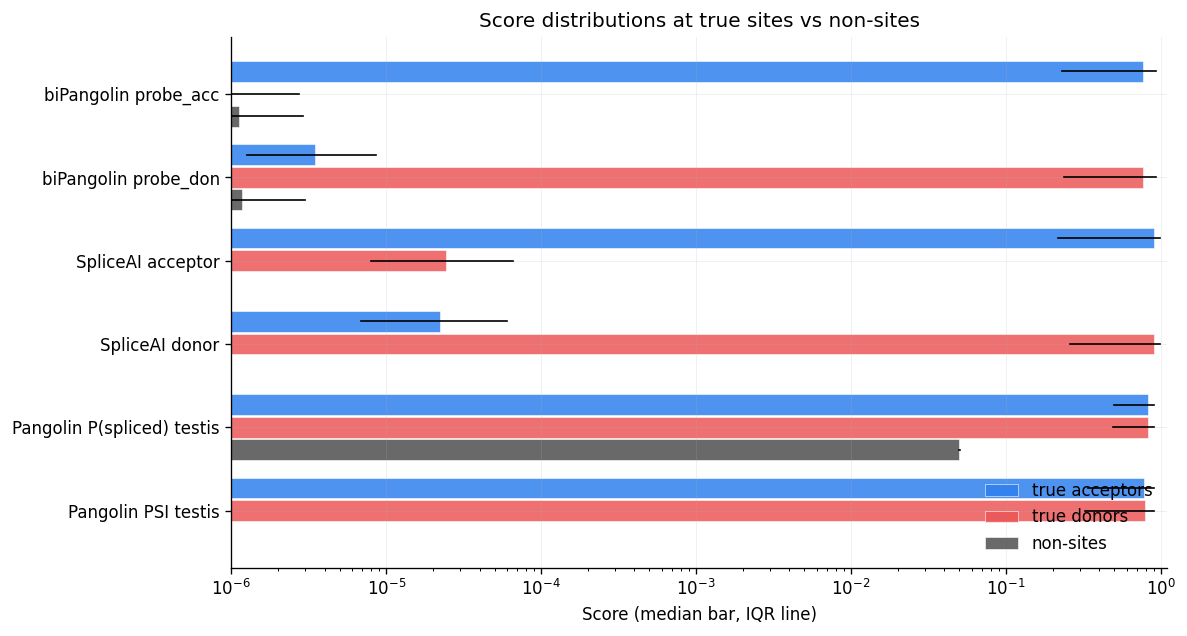

In [13]:
# Score distributions at true acceptor / donor sites (vs random non-sites).
# Uses raw probe (k=1) for biPangolin; SpliceAI as-is; Pangolin P(spliced) per tissue.
#
# Shows medians + interquartile bars on a log scale because most non-site scores are tiny.

def plot_score_distributions(arrays, n_none_subsample=200_000, seed=0):
    label = arrays["label"]
    rng = np.random.default_rng(seed)
    none_idx = np.where(label == 0)[0]
    if len(none_idx) > n_none_subsample:
        none_idx = rng.choice(none_idx, n_none_subsample, replace=False)
    acc_idx = np.where(label == 1)[0]
    don_idx = np.where(label == 2)[0]

    # (method label, array, score-of-interest is for which class)
    rows = [
        ("biPangolin probe_acc",         arrays["probe_acc"],         "acceptor"),
        ("biPangolin probe_don",         arrays["probe_don"],         "donor"),
        ("SpliceAI acceptor",            arrays["spliceai_acc"],      "acceptor"),
        ("SpliceAI donor",               arrays["spliceai_don"],      "donor"),
        ("Pangolin P(spliced) testis",   arrays["pangolin_p_testis"], "any"),
        ("Pangolin PSI testis",          arrays["pangolin_psi_testis"], "any"),
    ]

    fig, ax = plt.subplots(figsize=(10, 5.4))
    y_pos = np.arange(len(rows))
    width = 0.27
    eps = 1e-6

    for i, (name, arr, kind) in enumerate(rows):
        a = arr[acc_idx].astype(float)
        d = arr[don_idx].astype(float)
        n = arr[none_idx].astype(float)
        # drop NaN
        a = a[np.isfinite(a)]; d = d[np.isfinite(d)]; n = n[np.isfinite(n)]
        def stat(x):
            if len(x) == 0:
                return (np.nan, np.nan, np.nan)
            return np.quantile(x, [0.25, 0.5, 0.75])
        for off, (xs, color, lab) in enumerate([
            (a, ACC_COLOR, "true acceptors"),
            (d, DON_COLOR, "true donors"),
            (n, NONE_COLOR, "non-sites"),
        ]):
            q1, med, q3 = stat(xs)
            y = i + (off - 1) * width
            ax.barh(y, max(med, eps), height=width * 0.92, color=color,
                    edgecolor="white", linewidth=0.4, alpha=0.85,
                    label=lab if i == 0 else None)
            ax.plot([max(q1, eps), max(q3, eps)], [y, y], color="black", lw=1)

    ax.set_xscale("log")
    ax.set_xlim(eps, 1.1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([r[0] for r in rows])
    ax.invert_yaxis()
    ax.set_xlabel("Score (median bar, IQR line)")
    ax.legend(frameon=False, loc="lower right")
    ax.set_title("Score distributions at true sites vs non-sites")
    fig.tight_layout()
    return fig

fig = plot_score_distributions(bench_arrays)
save_figure(fig, "figure_benchmark_score_distributions")
plt.show()

  acceptor           biPangolin probe_acc k=108.13542142817668  AUC=0.7226  (16.3s)
  acceptor           SpliceAI acceptor                         AUC=0.6844  (7.0s)
  donor              biPangolin probe_don k=108.13542142817668  AUC=0.7100  (15.8s)
  donor              SpliceAI donor                            AUC=0.6779  (6.5s)
  any splice site    biPangolin 1-p_none k=108.13542142817668  AUC=0.7160  (11.9s)
  any splice site    SpliceAI max(A,D)                         AUC=0.6805  (7.4s)
  any splice site    Pangolin P(spliced) testis                AUC=0.7026  (11.9s)
  any splice site    Pangolin PSI testis                       AUC=0.7187  (8.9s)
  wrote bench_metrics/pr_curves_cache.npz
saved paper_figures/figure_benchmark_pr_curves.svg and paper_figures/figure_benchmark_pr_curves.png


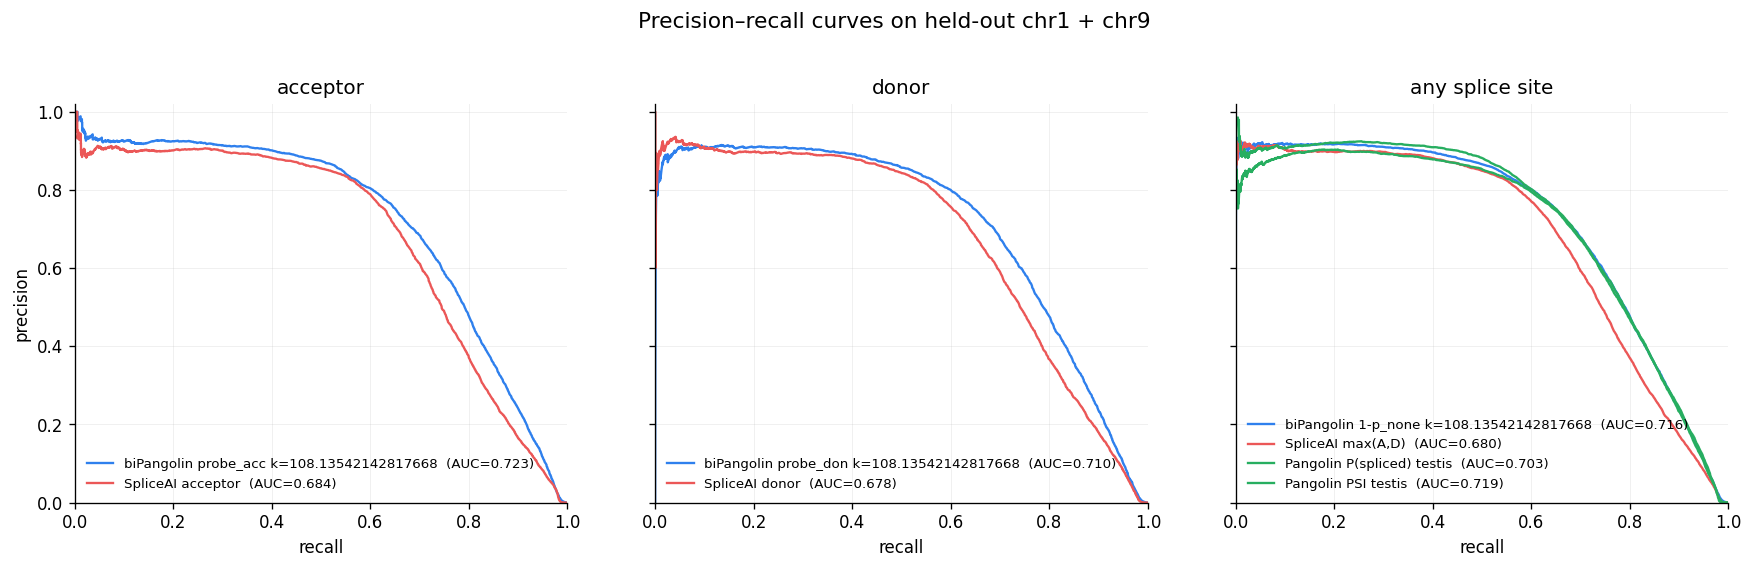

In [14]:
# PR curves overlaid: biPangolin probe vs SpliceAI vs Pangolin per tissue.
# Assumes bench_arrays was already loaded with the production k correction
# applied (load_bench_arrays default). Heavy lifting (sort + cumsum) cached to
# bench_metrics/pr_curves_cache.npz so re-running is instant.
# Delete the cache to recompute.

import time

_TRAPZ = getattr(np, "trapezoid", None) or np.trapz
_PR_CACHE = Path("bench_metrics/pr_curves_cache.npz")
_PR_CURVE_POINTS = 5000


def _pr_curve(score, y):
    mask = np.isfinite(score)
    if not mask.all():
        score = score[mask]; y = y[mask]
    order = np.argsort(-score, kind="quicksort")
    y_sorted = y[order].astype(np.int32, copy=False)
    tp = np.cumsum(y_sorted, dtype=np.int64)
    fp = np.cumsum(1 - y_sorted, dtype=np.int64)
    n_pos = max(int(y_sorted.sum()), 1)
    recall = tp / n_pos
    precision = tp / np.maximum(tp + fp, 1)
    return recall, precision


def _pr_auc_from_curve(recall, precision):
    return float(_TRAPZ(
        np.concatenate([[1.0], precision]),
        np.concatenate([[0.0], recall]),
    ))


def _downsample_curve(recall, precision, n_points=_PR_CURVE_POINTS):
    # Log-spaced indices so the elbow at low recall (top of the sorted array,
    # where the curve actually has structure) is captured densely. Linear
    # spacing across 10s of millions of ranks collapses the elbow into 1-2
    # points and produces triangular curves.
    n = len(recall)
    if n <= n_points:
        return recall, precision
    raw = np.geomspace(1, n, n_points).astype(np.int64) - 1
    idx = np.unique(np.clip(raw, 0, n - 1))
    return recall[idx], precision[idx]


def _series_key(name):
    return name.replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")


def build_pr_curves(arrays, force_recompute=False):
    if _PR_CACHE.exists() and not force_recompute:
        z = np.load(_PR_CACHE, allow_pickle=False)
        curves = {}
        for k in z.files:
            if not k.endswith("__recall"):
                continue
            base = k[:-len("__recall")]
            task, _, raw_name = base.partition("::")
            curves[base] = {
                "recall": z[base + "__recall"],
                "precision": z[base + "__precision"],
                "auc": float(z[base + "__auc"][0]),
                "task": task,
                "display_name": raw_name.replace("_", " "),
            }
        print(f"  loaded cached PR curves from {_PR_CACHE}")
        return curves

    label = arrays["label"]
    is_acc = (label == 1).astype(np.int8)
    is_don = (label == 2).astype(np.int8)
    is_any = (label != 0).astype(np.int8)

    # arrays is assumed pre-corrected by load_bench_arrays.
    bp_acc  = arrays["probe_acc"]
    bp_don  = arrays["probe_don"]
    bp_none = arrays["probe_none"]
    k = arrays.get("_correction_k", "?")

    spec = [
        ("acceptor",        is_acc, f"biPangolin probe_acc k={k}",            bp_acc),
        ("acceptor",        is_acc, "SpliceAI acceptor",                       arrays["spliceai_acc"]),
        ("donor",           is_don, f"biPangolin probe_don k={k}",            bp_don),
        ("donor",           is_don, "SpliceAI donor",                          arrays["spliceai_don"]),
        ("any splice site", is_any, f"biPangolin 1-p_none k={k}",             1.0 - bp_none),
        ("any splice site", is_any, "SpliceAI max(A,D)",                       np.maximum(arrays["spliceai_acc"], arrays["spliceai_don"])),
        ("any splice site", is_any, "Pangolin P(spliced) testis",              arrays["pangolin_p_testis"]),
        ("any splice site", is_any, "Pangolin PSI testis",                     arrays["pangolin_psi_testis"]),
    ]

    curves = {}
    save_dict = {}
    for task, y, name, score in spec:
        t0 = time.time()
        r, p = _pr_curve(score, y)
        auc = _pr_auc_from_curve(r, p)
        r_ds, p_ds = _downsample_curve(r, p)
        key = f"{task}::{_series_key(name)}"
        curves[key] = {"recall": r_ds.astype(np.float32),
                       "precision": p_ds.astype(np.float32),
                       "auc": auc,
                       "task": task,
                       "display_name": name}
        save_dict[key + "__recall"]    = curves[key]["recall"]
        save_dict[key + "__precision"] = curves[key]["precision"]
        save_dict[key + "__auc"]       = np.array([auc], dtype=np.float64)
        print(f"  {task:18s} {name:40s}  AUC={auc:.4f}  ({time.time()-t0:.1f}s)")

    _PR_CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez(_PR_CACHE, **save_dict)
    print(f"  wrote {_PR_CACHE}")
    return curves


def plot_benchmark_pr_curves(arrays, force_recompute=False):
    curves = build_pr_curves(arrays, force_recompute=force_recompute)

    colour_map = {
        "biPangolin": "#2f80ed",
        "SpliceAI":   "#eb5757",
        "Pangolin P": "#27ae60",
        "Pangolin PSI": "#9b51e0",
    }
    def _colour(name):
        for prefix, c in colour_map.items():
            if name.startswith(prefix):
                return c
        return "#888888"

    task_order = ["acceptor", "donor", "any splice site"]
    series_per_task = {t: [] for t in task_order}
    for d in curves.values():
        series_per_task.setdefault(d["task"], []).append(d)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
    for ax, task in zip(axes, task_order):
        for d in series_per_task[task]:
            name = d["display_name"]
            ax.plot(d["recall"], d["precision"], color=_colour(name), lw=1.4,
                    label=f"{name}  (AUC={d['auc']:.3f})")
        ax.set_title(task)
        ax.set_xlabel("recall")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        ax.legend(frameon=False, fontsize=8, loc="lower left")
    axes[0].set_ylabel("precision")
    fig.suptitle("Precision–recall curves on held-out chr1 + chr9", y=1.02, fontsize=13)
    fig.tight_layout()
    return fig


fig = plot_benchmark_pr_curves(bench_arrays)
save_figure(fig, "figure_benchmark_pr_curves")
plt.show()


## 7. Figure: acceptor-vs-donor discrimination at true splice sites

Supports the claim that *given a position is a true splice site, the probe assigns it to the correct class (acceptor vs donor) essentially every time*.

For each held-out true splice site (label = acceptor or donor), call it "acceptor" if `probe_acc > probe_don` and "donor" otherwise. Same procedure for SpliceAI as a reference. The signed difference `acc − don` is plotted alongside as a supporting density view.

This is a 2-class problem on a curated set (~46k positions across chr1+chr9), not the full chrom-wide binary detection task in §6.

In [15]:
# Load only the columns we need at true-splice-site positions, both chroms.
# Probe outputs are corrected with the production k (~502) at load time —
# argmax(acc, don) is k-invariant so confusion-matrix accuracy is identical to
# raw, but the filter cutoff in the top-N% confidence subset uses the corrected
# scale, and the signed-difference histogram reflects corrected probabilities.

def load_true_site_scores(scores_dir=BENCH_SCORES_DIR, chroms=None,
                          correction_k=None):
    if chroms is None:
        chroms = BENCH_CHROMS
    if correction_k is None:
        correction_k = _resolve_default_correction_k()
    cols = ["label", "probe_none", "probe_acc", "probe_don",
            "spliceai_acc", "spliceai_don"]
    out = {c: [] for c in cols}
    for chrom in chroms:
        path = scores_dir / f"{chrom}.parquet"
        if not path.exists():
            print(f"  [skip] {path} missing")
            continue
        t = pq.read_table(str(path), columns=cols)
        lbl = t["label"].to_numpy().astype(np.int8)
        mask = (lbl == 1) | (lbl == 2)
        for c in cols:
            arr = t[c].to_numpy()[mask]
            if c == "label":
                out[c].append(arr.astype(np.int8))
            else:
                out[c].append(arr.astype(np.float32))
    arrs = {c: np.concatenate(v) for c, v in out.items() if v}

    if correction_k != 1.0:
        k = np.float32(correction_k)
        pn, pa_, pd_ = arrs["probe_none"], arrs["probe_acc"], arrs["probe_don"]
        s = pn * k + pa_ + pd_
        s = np.maximum(s, np.float32(1e-12))
        arrs["probe_none"] = (pn * k) / s
        arrs["probe_acc"]  = pa_ / s
        arrs["probe_don"]  = pd_ / s
    arrs["_correction_k"] = correction_k
    return arrs


ad_arrays = load_true_site_scores()
n_acc = int((ad_arrays["label"] == 1).sum())
n_don = int((ad_arrays["label"] == 2).sum())
print(f"loaded {len(ad_arrays['label']):,} true splice sites  "
      f"(acceptors={n_acc:,}, donors={n_don:,}, "
      f"correction_k={ad_arrays['_correction_k']:.2f})")


loaded 46,288 true splice sites  (acceptors=23,235, donors=23,053, correction_k=108.14)


saved paper_figures/figure_ad_discrimination.svg and paper_figures/figure_ad_discrimination.png


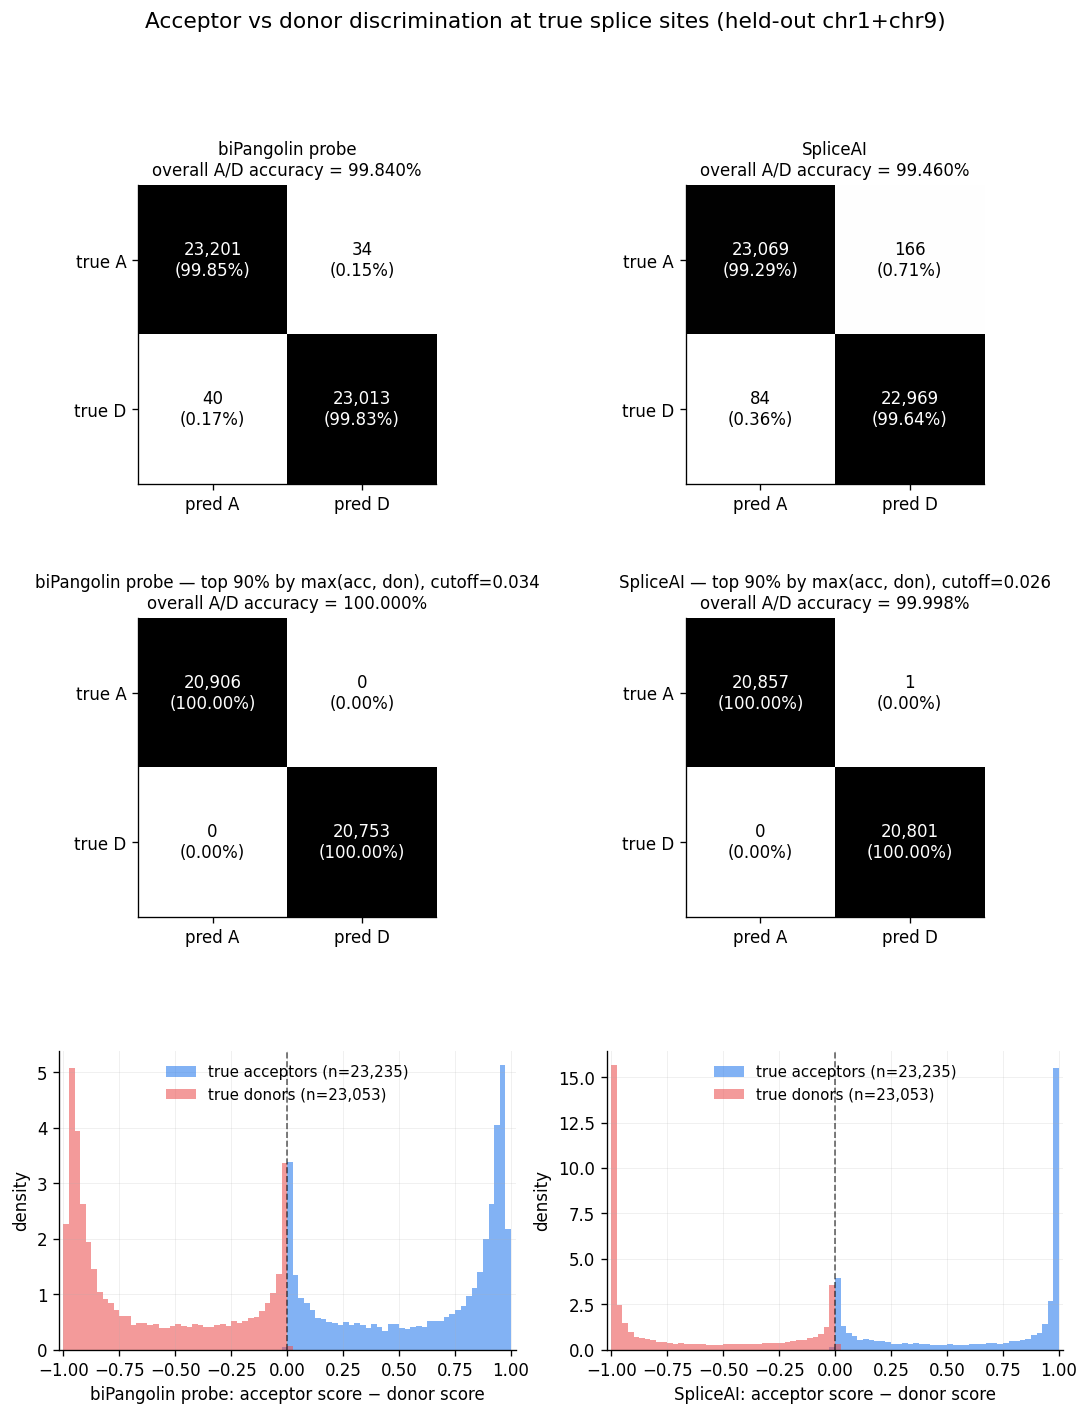

In [16]:
# Confusion matrices + signed-difference histograms for both methods.
# Three rows:
#   row 1: full confusion matrix (all true sites)
#   row 2: confusion matrix restricted to the top 90% of true sites by
#          per-method confidence (= max of acc / don score). Drops the bottom
#          decile where the method effectively says "this isn't a splice site"
#          and argmax(acc, don) is just noise.
#   row 3: signed-difference histogram (acc - don) coloured by true class.

KEEP_PCT_DEFAULT = 0.90


def _ad_predict(acc_scores, don_scores):
    return np.where(acc_scores > don_scores, 1, 2).astype(np.int8)


def _confusion_2class(true, pred):
    cm = np.zeros((2, 2), dtype=np.int64)
    for ti, tlab in enumerate((1, 2)):
        for pi, plab in enumerate((1, 2)):
            cm[ti, pi] = int(((true == tlab) & (pred == plab)).sum())
    return cm


def _draw_confusion(ax, cm, title):
    row_sums = cm.sum(axis=1).clip(1)
    cm_norm = cm / row_sums[:, None]
    overall_acc = float(np.diag(cm).sum() / max(cm.sum(), 1))
    ax.imshow(cm_norm, cmap="Greys", vmin=0, vmax=1, aspect="equal")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred A", "pred D"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["true A", "true D"])
    for i in range(2):
        for j in range(2):
            txt_color = "white" if cm_norm[i, j] > 0.55 else "black"
            ax.text(j, i, f"{cm[i, j]:,}\n({cm_norm[i, j]*100:.2f}%)",
                    ha="center", va="center", color=txt_color, fontsize=10)
    ax.set_title(f"{title}\noverall A/D accuracy = {overall_acc*100:.3f}%",
                 fontsize=10)
    ax.grid(False)


def plot_ad_discrimination(arrays, keep_pct=KEEP_PCT_DEFAULT):
    label = arrays["label"]
    is_acc = label == 1
    is_don = label == 2

    methods = [
        ("biPangolin probe", arrays["probe_acc"],   arrays["probe_don"]),
        ("SpliceAI",         arrays["spliceai_acc"], arrays["spliceai_don"]),
    ]

    fig, axes = plt.subplots(3, len(methods), figsize=(5.4 * len(methods), 12.6),
                              gridspec_kw={"height_ratios": [1, 1, 1], "hspace": 0.45})

    for col, (name, acc_s, don_s) in enumerate(methods):
        pred = _ad_predict(acc_s, don_s)

        # Row 1: full confusion matrix
        cm_full = _confusion_2class(label, pred)
        _draw_confusion(axes[0, col], cm_full, name)

        # Row 2: top-keep_pct by max(acc, don)
        confidence = np.maximum(acc_s, don_s)
        cutoff = float(np.quantile(confidence, 1.0 - keep_pct))
        keep = confidence >= cutoff
        cm_kept = _confusion_2class(label[keep], pred[keep])
        kept_title = (f"{name} — top {int(round(keep_pct*100))}%"
                      f" by max(acc, don), cutoff={cutoff:.3f}")
        _draw_confusion(axes[1, col], cm_kept, kept_title)

        # Row 3: signed-difference histogram
        ax = axes[2, col]
        diff = (acc_s - don_s)
        bins = np.linspace(-1, 1, 81)
        ax.hist(diff[is_acc], bins=bins, color=ACC_COLOR, alpha=0.6,
                label=f"true acceptors (n={int(is_acc.sum()):,})", density=True)
        ax.hist(diff[is_don], bins=bins, color=DON_COLOR, alpha=0.6,
                label=f"true donors (n={int(is_don.sum()):,})", density=True)
        ax.axvline(0, color="black", lw=1, ls="--", alpha=0.6)
        ax.set_xlabel(f"{name}: acceptor score − donor score")
        ax.set_ylabel("density")
        ax.set_xlim(-1.02, 1.02)
        ax.legend(frameon=False, fontsize=9, loc="upper center")

    fig.suptitle("Acceptor vs donor discrimination at true splice sites "
                 "(held-out chr1+chr9)", y=0.995, fontsize=13)
    return fig


fig = plot_ad_discrimination(ad_arrays)
save_figure(fig, "figure_ad_discrimination")
plt.show()


## 8. Correlation analysis across models

Spearman ρ between every per-position score column, computed by streaming `bench_scores/*.parquet` in 1M-row batches via `benchmark/bench_correlations.py`. Spearman (rank-based) is far less sensitive than Pearson to the probe's softmax saturation and to the choice of Bayesian correction k.

Two panels:

- **Panel A** — full matrix across all model outputs: ensemble probe, per-tissue Pangolin P/PSI, `spliceai_max = max(spliceai_acc, spliceai_don)`, and the corresponding `probe_max`. Bird's-eye view.
- **Panel B** — two matrices, one for acceptor and one for donor, comparing per-tissue Pangolin P (and ensemble) against per-tissue probe outputs (and ensemble) plus SpliceAI. If the parquet was produced with `bench_score.py --per-tissue-probes`, the per-tissue probes show up; otherwise only the global ensemble probe appears.

Each panel can be plotted on four subsets: `all`, `acceptors`, `donors`, `nonsites`.

If `bench_metrics/correlations.npz` doesn't exist or is stale:

```bash
python benchmark/bench_correlations.py --scores bench_scores/ --out bench_metrics/correlations.npz
```

In [17]:
# Load correlation matrices produced by benchmark/bench_correlations.py.
# Values are Spearman ρ.

CORR_NPZ = Path("bench_metrics/correlations.npz")
if not CORR_NPZ.exists():
    raise FileNotFoundError(
        f"{CORR_NPZ} not found. Run:\n"
        "  python benchmark/bench_correlations.py --scores bench_scores/ --out bench_metrics/correlations.npz"
    )

corr_data = np.load(CORR_NPZ)
corr_columns = list(corr_data["columns"])
corr_counts = {s: int(corr_data[f"n_{s}"][0]) for s in ("all", "acceptors", "donors", "nonsites")}
print(f"loaded {CORR_NPZ}")
print(f"  columns ({len(corr_columns)}): {corr_columns}")
print(f"  subset counts: {corr_counts}")

def _corr_submatrix(subset, column_names):
    full = corr_data[f"corr_{subset}"]
    idx = [corr_columns.index(c) for c in column_names]
    return full[np.ix_(idx, idx)]

def _plot_corr_heatmap(ax, M, labels, title=None, vmin=-1, vmax=1, cmap="RdBu_r",
                       annotate=True, annot_fontsize=8):
    im = ax.imshow(M, vmin=vmin, vmax=vmax, cmap=cmap, aspect="equal")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.grid(False)
    if annotate:
        # Text-colour threshold = midpoint of the actual colour-mapped range.
        lo = im.norm.vmin if im.norm.vmin is not None else float(np.nanmin(M))
        hi = im.norm.vmax if im.norm.vmax is not None else float(np.nanmax(M))
        thr = lo + 0.55 * (hi - lo)
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                v = M[i, j]
                if np.isfinite(v):
                    color = "white" if v > thr else "black"
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                            color=color, fontsize=annot_fontsize)
    if title:
        ax.set_title(title, fontsize=10)
    return im


loaded bench_metrics/correlations.npz
  columns (33): [np.str_('probe_none'), np.str_('probe_acc'), np.str_('probe_don'), np.str_('pangolin_p_heart'), np.str_('pangolin_p_liver'), np.str_('pangolin_p_brain'), np.str_('pangolin_p_testis'), np.str_('pangolin_psi_heart'), np.str_('pangolin_psi_liver'), np.str_('pangolin_psi_brain'), np.str_('pangolin_psi_testis'), np.str_('spliceai_acc'), np.str_('spliceai_don'), np.str_('probe_none_heart'), np.str_('probe_acc_heart'), np.str_('probe_don_heart'), np.str_('probe_none_liver'), np.str_('probe_acc_liver'), np.str_('probe_don_liver'), np.str_('probe_none_brain'), np.str_('probe_acc_brain'), np.str_('probe_don_brain'), np.str_('probe_none_testis'), np.str_('probe_acc_testis'), np.str_('probe_don_testis'), np.str_('spliceai_max'), np.str_('probe_max'), np.str_('pangolin_p_ensemble'), np.str_('pangolin_psi_ensemble'), np.str_('probe_max_heart'), np.str_('probe_max_liver'), np.str_('probe_max_brain'), np.str_('probe_max_testis')]
  subset counts: 

saved paper_figures/figure_correlation_panel_a.svg and paper_figures/figure_correlation_panel_a.png


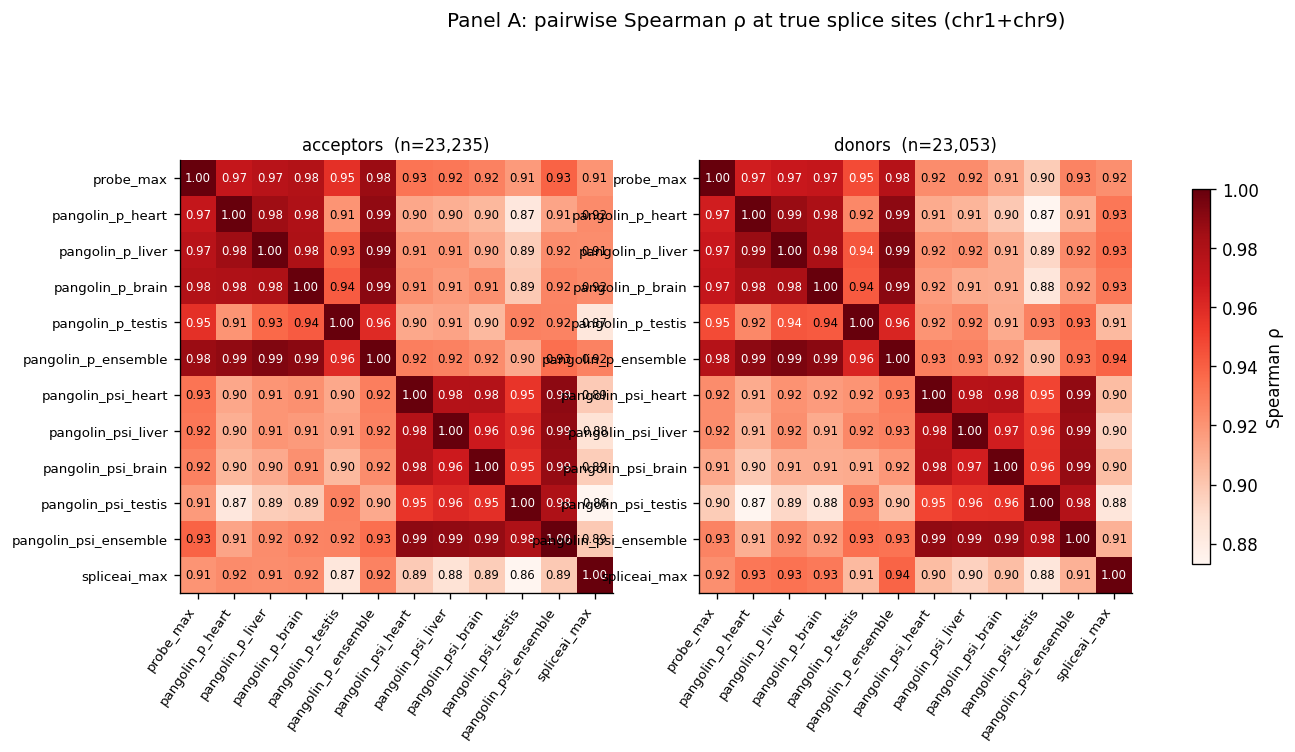

In [18]:
# Panel A: Spearman ρ heatmap at true splice-site positions.
# Auto-scaled to the actual range, white→red colormap.

def _panel_a_columns():
    keep = []
    keep.append("probe_max")
    for t in ("heart", "liver", "brain", "testis"):
        if f"pangolin_p_{t}" in corr_columns:
            keep.append(f"pangolin_p_{t}")
    if "pangolin_p_ensemble" in corr_columns:
        keep.append("pangolin_p_ensemble")
    for t in ("heart", "liver", "brain", "testis"):
        if f"pangolin_psi_{t}" in corr_columns:
            keep.append(f"pangolin_psi_{t}")
    if "pangolin_psi_ensemble" in corr_columns:
        keep.append("pangolin_psi_ensemble")
    keep.append("spliceai_max")
    return [c for c in keep if c in corr_columns]

def plot_panel_a(subsets=("acceptors", "donors")):
    cols = _panel_a_columns()
    n = len(subsets)
    fig, axes = plt.subplots(1, n, figsize=(6.4 * n, 5.8))
    if n == 1:
        axes = [axes]
    for ax, subset in zip(axes, subsets):
        M = _corr_submatrix(subset, cols)
        im = _plot_corr_heatmap(
            ax, M, cols,
            title=f"{subset}  (n={corr_counts[subset]:,})",
            annotate=True, annot_fontsize=7,
            vmin=None, vmax=None, cmap="Reds",
        )
    fig.colorbar(im, ax=axes, shrink=0.7, label="Spearman ρ")
    fig.suptitle("Panel A: pairwise Spearman ρ at true splice sites (chr1+chr9)",
                 y=1.02, fontsize=12)
    return fig

fig = plot_panel_a()
save_figure(fig, "figure_correlation_panel_a")
plt.show()


saved paper_figures/figure_correlation_panel_b.svg and paper_figures/figure_correlation_panel_b.png


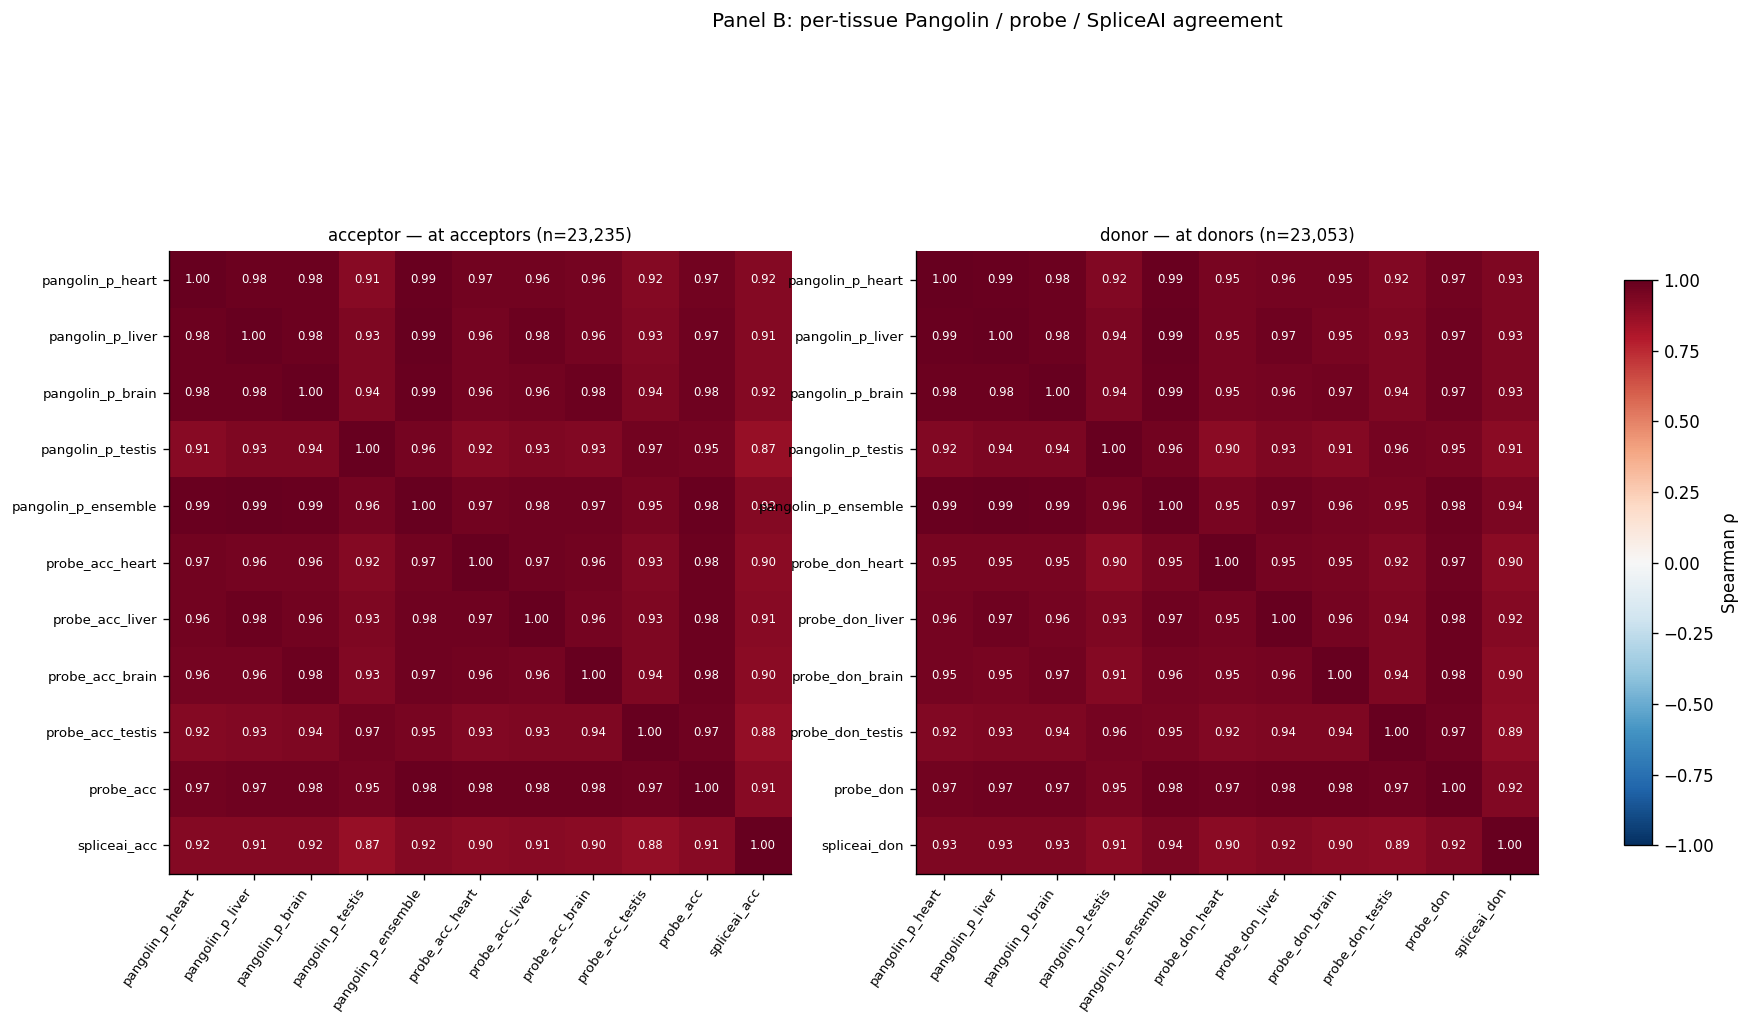

In [19]:
# Panel B: acceptor and donor matrices side by side.
# Rows/cols include per-tissue Pangolin P (+ ensemble), per-tissue probe (+ ensemble) if present, and SpliceAI.

def _panel_b_columns(channel):
    """channel: 'acc' or 'don'. Returns columns in display order."""
    cols = []
    # Pangolin P per tissue + ensemble
    for t in ("heart", "liver", "brain", "testis"):
        if f"pangolin_p_{t}" in corr_columns:
            cols.append(f"pangolin_p_{t}")
    if "pangolin_p_ensemble" in corr_columns:
        cols.append("pangolin_p_ensemble")
    # Probe per tissue + ensemble (only if per-tissue probes were stored)
    for t in ("heart", "liver", "brain", "testis"):
        c = f"probe_{channel}_{t}"
        if c in corr_columns:
            cols.append(c)
    cols.append(f"probe_{channel}")    # ensemble
    # SpliceAI
    cols.append(f"spliceai_{channel}")
    return [c for c in cols if c in corr_columns]

def plot_panel_b(subset_acceptor="acceptors", subset_donor="donors"):
    cols_a = _panel_b_columns("acc")
    cols_d = _panel_b_columns("don")
    width_per_panel = 0.7 * max(len(cols_a), len(cols_d)) + 1.5
    fig, axes = plt.subplots(1, 2, figsize=(2 * width_per_panel, width_per_panel * 0.95))
    im = _plot_corr_heatmap(
        axes[0], _corr_submatrix(subset_acceptor, cols_a), cols_a,
        title=f"acceptor — at {subset_acceptor} (n={corr_counts[subset_acceptor]:,})",
        annot_fontsize=7 if len(cols_a) > 6 else 9,
    )
    _plot_corr_heatmap(
        axes[1], _corr_submatrix(subset_donor, cols_d), cols_d,
        title=f"donor — at {subset_donor} (n={corr_counts[subset_donor]:,})",
        annot_fontsize=7 if len(cols_d) > 6 else 9,
    )
    fig.colorbar(im, ax=axes, shrink=0.7, label="Spearman ρ")
    fig.suptitle("Panel B: per-tissue Pangolin / probe / SpliceAI agreement", y=1.02, fontsize=12)
    return fig

fig = plot_panel_b()
save_figure(fig, "figure_correlation_panel_b")
plt.show()

In [ ]:
# Scatter visualisations behind the Spearman ρ values: four chosen method pairs,
# coloured by true class (acceptor / donor). Restricted to true splice sites.
# Probe outputs have the default Bayesian k correction applied (k read from
# optimal_correction.json — same value the runner uses in production).
# Memory: ~46k positions × ~16 cols × float32 ≈ 3 MB.


def _load_default_k():
    """Resolve the production k value from optimal_correction.json."""
    candidates = [
        Path("src/bipangolin/data/probes/optimal_correction.json"),
        Path("bipangolin_probes/optimal_correction.json"),
    ]
    for p in candidates:
        if p.exists():
            with open(p) as f:
                return float(json.load(f)["empirical_sweep"]["best_k"])
    return 502.0  # safe fallback


def _correct_triple(p_none, p_acc, p_don, k):
    """Apply Bayesian none-class correction; returns (none, acc, don) at given k."""
    if k == 1.0:
        return p_none, p_acc, p_don
    k = np.float32(k)
    s = p_none * k + p_acc + p_don
    s = np.maximum(s, np.float32(1e-12))
    return (p_none * k) / s, p_acc / s, p_don / s


def _load_scatter_arrays(scores_dir=BENCH_SCORES_DIR, chroms=("chr1", "chr9")):
    pq_schema = pq.read_schema(str(scores_dir / f"{chroms[0]}.parquet")).names
    needed_native = [
        "label",
        "probe_none", "probe_acc", "probe_don",
        "spliceai_acc", "spliceai_don",
        "pangolin_p_heart", "pangolin_p_liver", "pangolin_p_brain", "pangolin_p_testis",
        "pangolin_psi_heart", "pangolin_psi_liver", "pangolin_psi_brain", "pangolin_psi_testis",
    ]
    tissues = ("heart", "liver", "brain", "testis")
    has_pt = all(f"probe_{ch}_{t}" in pq_schema
                 for ch in ("none", "acc", "don") for t in tissues)
    has_pt_psi = all(f"probe_{ch}_psi_{t}" in pq_schema
                     for ch in ("none", "acc", "don") for t in tissues)
    if has_pt:
        for t in tissues:
            needed_native += [f"probe_none_{t}", f"probe_acc_{t}", f"probe_don_{t}"]
    if has_pt_psi:
        for t in tissues:
            needed_native += [f"probe_none_psi_{t}", f"probe_acc_psi_{t}", f"probe_don_psi_{t}"]
    out = {c: [] for c in needed_native}
    for chrom in chroms:
        path = scores_dir / f"{chrom}.parquet"
        if not path.exists():
            print(f"  [skip] {path} missing")
            continue
        t = pq.read_table(str(path), columns=needed_native)
        lbl = t["label"].to_numpy().astype(np.int8)
        mask = (lbl == 1) | (lbl == 2)
        for c in needed_native:
            arr = t[c].to_numpy()[mask]
            out[c].append(arr.astype(np.int8 if c == "label" else np.float32))
    arrs = {c: np.concatenate(v) for c, v in out.items() if v}

    # Apply default-k correction to all probe triples (ensemble + per-tissue
    # P-side + per-tissue PSI-side).
    k = _load_default_k()
    arrs["_correction_k"] = k
    cn, ca, cd = _correct_triple(arrs["probe_none"], arrs["probe_acc"], arrs["probe_don"], k)
    arrs["probe_none"], arrs["probe_acc"], arrs["probe_don"] = cn, ca, cd
    if has_pt:
        for t in tissues:
            cn, ca, cd = _correct_triple(
                arrs[f"probe_none_{t}"], arrs[f"probe_acc_{t}"], arrs[f"probe_don_{t}"], k)
            arrs[f"probe_none_{t}"] = cn
            arrs[f"probe_acc_{t}"] = ca
            arrs[f"probe_don_{t}"] = cd
    if has_pt_psi:
        for t in tissues:
            cn, ca, cd = _correct_triple(
                arrs[f"probe_none_psi_{t}"], arrs[f"probe_acc_psi_{t}"], arrs[f"probe_don_psi_{t}"], k)
            arrs[f"probe_none_psi_{t}"] = cn
            arrs[f"probe_acc_psi_{t}"] = ca
            arrs[f"probe_don_psi_{t}"] = cd

    # Derived columns (from corrected values)
    p_cols = [arrs[f"pangolin_p_{t}"] for t in tissues]
    psi_cols = [arrs[f"pangolin_psi_{t}"] for t in tissues]
    arrs["pangolin_p_ensemble"]   = np.mean(np.stack(p_cols, axis=0), axis=0)
    arrs["pangolin_psi_ensemble"] = np.mean(np.stack(psi_cols, axis=0), axis=0)
    arrs["probe_max"]    = np.maximum(arrs["probe_acc"], arrs["probe_don"])
    arrs["spliceai_max"] = np.maximum(arrs["spliceai_acc"], arrs["spliceai_don"])
    if has_pt:
        for t in tissues:
            arrs[f"probe_max_{t}"] = np.maximum(arrs[f"probe_acc_{t}"], arrs[f"probe_don_{t}"])
    if has_pt_psi:
        for t in tissues:
            arrs[f"probe_max_psi_{t}"] = np.maximum(arrs[f"probe_acc_psi_{t}"], arrs[f"probe_don_psi_{t}"])
    return arrs, has_pt, has_pt_psi


def _spearman_rho(x, y):
    """Quick exact Spearman ρ on small arrays (only ~46k points here)."""
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan
    xr = np.argsort(np.argsort(x[mask], kind="quicksort"))
    yr = np.argsort(np.argsort(y[mask], kind="quicksort"))
    xr = xr.astype(np.float64); yr = yr.astype(np.float64)
    xr -= xr.mean(); yr -= yr.mean()
    denom = np.sqrt((xr * xr).sum() * (yr * yr).sum())
    return float((xr * yr).sum() / denom) if denom > 0 else np.nan


def plot_correlation_scatters(arrs, has_pt):
    label = arrs["label"]
    is_acc = label == 1
    is_don = label == 2

    pairs = [
        ("probe_max",  "pangolin_p_ensemble",  "biPangolin probe vs Pangolin P (ensemble)"),
        ("probe_max",  "spliceai_max",         "biPangolin probe vs SpliceAI"),
    ]
    if has_pt:
        pairs.append(("probe_max_testis", "probe_max",
                      "per-tissue probe (testis) vs ensemble probe"))
    else:
        pairs.append(("pangolin_p_testis", "pangolin_p_ensemble",
                      "[no per-tissue probes] Pangolin P testis vs ensemble"))
    pairs.append(("pangolin_p_ensemble", "pangolin_psi_ensemble",
                  "Pangolin P vs PSI (ensemble)"))

    n = len(pairs)
    fig, axes = plt.subplots(1, n, figsize=(3.4 * n, 3.6))
    for ax, (xkey, ykey, title) in zip(axes, pairs):
        x = arrs[xkey]; y = arrs[ykey]
        ax.scatter(x[is_don], y[is_don], s=4, alpha=0.10, c=DON_COLOR,
                   edgecolors="none", label=f"donors (n={int(is_don.sum()):,})")
        ax.scatter(x[is_acc], y[is_acc], s=4, alpha=0.10, c=ACC_COLOR,
                   edgecolors="none", label=f"acceptors (n={int(is_acc.sum()):,})")
        lo = float(min(np.nanmin(x), np.nanmin(y)))
        hi = float(max(np.nanmax(x), np.nanmax(y)))
        ax.plot([lo, hi], [lo, hi], color="#888888", lw=0.8, ls="--", zorder=0)
        rho = _spearman_rho(x, y)
        ax.text(0.04, 0.96, f"ρ = {rho:.3f}",
                transform=ax.transAxes, va="top", ha="left",
                fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.8))
        ax.set_xlabel(xkey, fontsize=9)
        ax.set_ylabel(ykey, fontsize=9)
        ax.set_title(title, fontsize=10)
        ax.set_xlim(lo - 0.02, hi + 0.02)
        ax.set_ylim(lo - 0.02, hi + 0.02)
        ax.set_aspect("equal")
        if ax is axes[0]:
            leg = ax.legend(frameon=False, fontsize=8, loc="lower right",
                            markerscale=2)
            for lh in leg.legend_handles:
                lh.set_alpha(0.9)
    fig.suptitle(f"Pairwise scatter at true splice sites (chr1+chr9, probe k={arrs['_correction_k']:.1f})",
                 y=1.04, fontsize=12)
    fig.tight_layout()
    return fig


scatter_arrays, _has_pt, _has_pt_psi = _load_scatter_arrays()
print(f"  loaded {len(scatter_arrays['label']):,} true splice sites  "
      f"(per-tissue P-side probes: {_has_pt}, PSI-side probes: {_has_pt_psi}, "
      f"correction_k={scatter_arrays['_correction_k']:.2f})")
fig = plot_correlation_scatters(scatter_arrays, _has_pt)
save_figure(fig, "figure_correlation_scatters")
plt.show()


In [ ]:
# Tissue-specificity check: does each tissue probe correlate more strongly with
# its matched-tissue Pangolin output than with mismatched tissues?
#
# Important: the LEFT panel uses the P-tuned probe (`probe_max_{tissue}`) and
# compares it against Pangolin P(spliced). The RIGHT panel uses the PSI-tuned
# probe (`probe_max_psi_{tissue}`) against Pangolin PSI. Each side uses the
# probe trained on activations from the corresponding Pangolin model
# fine-tune, so the comparison is apples-to-apples.
#
# If the parquet doesn't have PSI-side probes (older bench_score run), the
# right panel falls back to the P-tuned probe with a warning in the title.

def plot_tissue_probe_pangolin_corr(arrs, has_pt, has_pt_psi):
    if not has_pt:
        print("  [skip] per-tissue probe columns not in parquet — "
              "rerun bench_score.py with --per-tissue-probes")
        return None

    label = arrs["label"]
    site_mask = label != 0
    tissues = ("heart", "liver", "brain", "testis")

    rho_p   = np.full((4, 4), np.nan)
    rho_psi = np.full((4, 4), np.nan)
    # LEFT panel: P-tuned probe vs Pangolin P
    for i, pt in enumerate(tissues):
        probe = arrs[f"probe_max_{pt}"][site_mask]
        for j, pgt in enumerate(tissues):
            rho_p[i, j] = _spearman_rho(probe, arrs[f"pangolin_p_{pgt}"][site_mask])
    # RIGHT panel: PSI-tuned probe vs Pangolin PSI (or fallback)
    psi_probe_key = (lambda t: f"probe_max_psi_{t}") if has_pt_psi else (lambda t: f"probe_max_{t}")
    for i, pt in enumerate(tissues):
        probe = arrs[psi_probe_key(pt)][site_mask]
        for j, pgt in enumerate(tissues):
            rho_psi[i, j] = _spearman_rho(probe, arrs[f"pangolin_psi_{pgt}"][site_mask])

    tissue_colors = {"heart": "#e74c3c", "liver": "#f39c12",
                     "brain": "#9b59b6", "testis": "#3498db"}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharey=False)
    x = np.arange(4)
    width = 0.20

    panel_specs = [
        (axes[0], rho_p,   "Per-tissue probe vs Pangolin P(spliced)",
         "P-tuned probe"),
        (axes[1], rho_psi, "Per-tissue probe vs Pangolin PSI",
         "PSI-tuned probe" if has_pt_psi else "P-tuned probe [PSI-side probes MISSING — re-run bench_score]"),
    ]
    for ax, M, title, subtitle in panel_specs:
        for j, pgt in enumerate(tissues):
            offset = (j - 1.5) * width
            colour = tissue_colors[pgt]
            for i, pt in enumerate(tissues):
                v = M[i, j]
                edge_w = 1.6 if i == j else 0.5
                edge_c = "black" if i == j else "white"
                ax.bar(x[i] + offset, v, width=width,
                       color=colour, edgecolor=edge_c, linewidth=edge_w,
                       label=f"Pangolin {pgt}" if i == 0 else None)
            for i, v in enumerate(M[:, j]):
                ax.text(x[i] + offset, v + 0.0008, f"{v:.3f}",
                        ha="center", va="bottom", fontsize=6.5)
        ax.set_xticks(x)
        ax.set_xticklabels([f"probe\n{t}" for t in tissues])
        ax.set_title(f"{title}\n({subtitle})", fontsize=10)
        ax.set_ylabel("Spearman ρ at true sites")
        lo = float(np.nanmin(M)); hi = float(np.nanmax(M))
        pad = max(0.005, 0.05 * (hi - lo))
        ax.set_ylim(lo - pad, hi + 2 * pad)
        ax.legend(frameon=False, fontsize=8, ncols=4, loc="upper center",
                  bbox_to_anchor=(0.5, -0.08))
        ax.grid(axis="x", visible=False)

    fig.suptitle("Tissue-specificity of probe outputs at true splice sites "
                 "(chr1+chr9, black-outlined bars = matched tissue)",
                 y=1.00, fontsize=12)
    fig.tight_layout()
    return fig


fig = plot_tissue_probe_pangolin_corr(scatter_arrays, _has_pt, _has_pt_psi)
if fig is not None:
    save_figure(fig, "figure_tissue_probe_pangolin_corr")
    plt.show()
